# Analysing data

### Libraries

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import plotly.express as px
import geopandas as gpd # NEEDS Installation of geopandas and its dependencies. Run # pip install geopandas in your terminal
import plotly.graph_objects as go
import pycountry
import geodatasets #NEEDS INSTALLATION of geodatasets. Run # pip install geodatasets in your terminal


### World bank data

In [55]:
#Import from worldbank.ipynb to get the world_bank_pivot dataframe, which contains the GDP per capita data for different countries and years. We will use this data to analyze the relationship between GDP per capita and job creation in our jobs dataset.

world_bank_pivot = pd.read_csv("world_bank_data.csv")
world_bank_pivot.head(10)


,country,gdp_per_capita,inflation_cpi,population,unemployment_rate,youth_unemployment
0,Austria,58268.878765,2.937916,9177982.0,5.200,10.864
1,Belgium,56614.567950,3.143491,11858610.0,5.700,17.418
2,France,46103.084086,1.999049,68551653.0,7.400,19.342
3,Germany,56103.732318,2.256498,83516593.0,3.400,6.910
4,Italy,40385.341396,0.982373,58952704.0,6.500,20.316
5,Netherlands,67520.421896,3.347543,17993485.0,3.700,8.683
6,Poland,25103.565661,3.790609,36559233.0,2.807,10.656
7,Spain,35326.768307,2.774178,48848840.0,11.400,26.519
8,Switzerland,103998.186686,1.062340,9005582.0,4.343,8.231
9,United Kingdom,53246.367615,3.271573,69226000.0,4.361,14.290


### Jobs data

In [56]:
#First we load the cleaned jobs dataset to analyze it
jobs_df_clean = pd.read_csv("jobs_clean.csv")
jobs_df_clean.head()

,Unnamed: 0,id,title,contract_type,description,created,clean_country,clean_salary,extracted_skills,work_mode,...,clean_city,clean_company,title_clean,job_category,min_salary,max_salary,currency,exchange_rate,MIN_EUR,MAX_EUR
0,0,5753281217,Data Analyst (m/w/d),NaN,Bei STRABAG bauen rund 89.000 Menschen an mehr...,2026-06-05 16:40:19,AT,Not Found,"GIT, OTHER",Remote,...,Österreich,STRABAG BRVZ GMBH,data analyst,data analyst,Not Found,NaN,EUR,1.0,NaN,NaN
1,1,5753281216,Data Analyst (m/w/d),NaN,Bei STRABAG bauen rund 89.000 Menschen an mehr...,2026-06-05 16:40:19,AT,Not Found,"GIT, OTHER",Remote,...,Spittal an der Drau,STRABAG BRVZ GMBH,data analyst,data analyst,Not Found,NaN,EUR,1.0,NaN,NaN
2,2,5762094132,Data Analyst - MS PowerBI (m/w/d),NaN,Baustoff + Metall ist ein hoch spezialisierter...,2026-06-13 06:58:14,AT,Not Found,"SQL, OTHER",Unspecified,...,"Wien, Österreich",Baustoff + Metall Gesellschaft m.b.H. Österrei...,data analyst ms powerbi,data analyst,Not Found,NaN,EUR,1.0,NaN,NaN
3,3,5727781690,Data Analyst (m/w/d),permanent,Data Analyst (m/w/d)\nJobs fürs Leben\nAuf der...,2026-05-13 08:03:25,AT,Not Found,SQL,Onsite,...,"Josefstadt, Wien",ÖSW Österreichisches Siedlungswerk Gemeinnützi...,data analyst,data analyst,Not Found,NaN,EUR,1.0,NaN,NaN
4,4,5758608143,Data Analyst,NaN,"What are you working on?\nGenres: Casual, Puzz...",2026-06-10 17:18:19,AT,Not Found,"PYTHON, SQL, TABLEAU, LOOKER",Unspecified,...,Österreich,Hitapps,data analyst,data analyst,Not Found,NaN,EUR,1.0,NaN,NaN


In [57]:
jobs_df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6718 entries, 0 to 6717
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          6718 non-null   int64  
 1   id                  6718 non-null   int64  
 2   title               6718 non-null   object 
 3   contract_type       1700 non-null   object 
 4   description         6718 non-null   object 
 5   created             6718 non-null   object 
 6   clean_country       6718 non-null   object 
 7   clean_salary        6718 non-null   object 
 8   extracted_skills    6718 non-null   object 
 9   work_mode           6718 non-null   object 
 10  seniority_level     6718 non-null   object 
 11  extracted_contract  6718 non-null   object 
 12  year_week           6718 non-null   object 
 13  clean_city          6718 non-null   object 
 14  clean_company       6718 non-null   object 
 15  title_clean         6718 non-null   object 
 16  job_ca

#### Filtering data to 2026

In [58]:
#Let's filter the jobs dataset to only include jobs created in 2026, 
#as we are interested in analyzing the job market for that year.
jobs_df_clean["created"] = (
    pd.to_datetime( jobs_df_clean["created"], errors="coerce", utc=True)
    .dt.tz_localize(None))

jobs_2026 = jobs_df_clean[jobs_df_clean["created"].dt.year == 2026]
jobs_2026.head()

,Unnamed: 0,id,title,contract_type,description,created,clean_country,clean_salary,extracted_skills,work_mode,...,clean_city,clean_company,title_clean,job_category,min_salary,max_salary,currency,exchange_rate,MIN_EUR,MAX_EUR
0,0,5753281217,Data Analyst (m/w/d),NaN,Bei STRABAG bauen rund 89.000 Menschen an mehr...,2026-06-05 16:40:19,AT,Not Found,"GIT, OTHER",Remote,...,Österreich,STRABAG BRVZ GMBH,data analyst,data analyst,Not Found,NaN,EUR,1.0,NaN,NaN
1,1,5753281216,Data Analyst (m/w/d),NaN,Bei STRABAG bauen rund 89.000 Menschen an mehr...,2026-06-05 16:40:19,AT,Not Found,"GIT, OTHER",Remote,...,Spittal an der Drau,STRABAG BRVZ GMBH,data analyst,data analyst,Not Found,NaN,EUR,1.0,NaN,NaN
2,2,5762094132,Data Analyst - MS PowerBI (m/w/d),NaN,Baustoff + Metall ist ein hoch spezialisierter...,2026-06-13 06:58:14,AT,Not Found,"SQL, OTHER",Unspecified,...,"Wien, Österreich",Baustoff + Metall Gesellschaft m.b.H. Österrei...,data analyst ms powerbi,data analyst,Not Found,NaN,EUR,1.0,NaN,NaN
3,3,5727781690,Data Analyst (m/w/d),permanent,Data Analyst (m/w/d)\nJobs fürs Leben\nAuf der...,2026-05-13 08:03:25,AT,Not Found,SQL,Onsite,...,"Josefstadt, Wien",ÖSW Österreichisches Siedlungswerk Gemeinnützi...,data analyst,data analyst,Not Found,NaN,EUR,1.0,NaN,NaN
4,4,5758608143,Data Analyst,NaN,"What are you working on?\nGenres: Casual, Puzz...",2026-06-10 17:18:19,AT,Not Found,"PYTHON, SQL, TABLEAU, LOOKER",Unspecified,...,Österreich,Hitapps,data analyst,data analyst,Not Found,NaN,EUR,1.0,NaN,NaN


In [59]:
# Further filter to only include data analyst jobs
data_analyst_jobs = jobs_2026[jobs_2026["job_category"].str.lower() == "data analyst"].copy()

data_analyst_jobs.head()


,Unnamed: 0,id,title,contract_type,description,created,clean_country,clean_salary,extracted_skills,work_mode,...,clean_city,clean_company,title_clean,job_category,min_salary,max_salary,currency,exchange_rate,MIN_EUR,MAX_EUR
0,0,5753281217,Data Analyst (m/w/d),NaN,Bei STRABAG bauen rund 89.000 Menschen an mehr...,2026-06-05 16:40:19,AT,Not Found,"GIT, OTHER",Remote,...,Österreich,STRABAG BRVZ GMBH,data analyst,data analyst,Not Found,NaN,EUR,1.0,NaN,NaN
1,1,5753281216,Data Analyst (m/w/d),NaN,Bei STRABAG bauen rund 89.000 Menschen an mehr...,2026-06-05 16:40:19,AT,Not Found,"GIT, OTHER",Remote,...,Spittal an der Drau,STRABAG BRVZ GMBH,data analyst,data analyst,Not Found,NaN,EUR,1.0,NaN,NaN
2,2,5762094132,Data Analyst - MS PowerBI (m/w/d),NaN,Baustoff + Metall ist ein hoch spezialisierter...,2026-06-13 06:58:14,AT,Not Found,"SQL, OTHER",Unspecified,...,"Wien, Österreich",Baustoff + Metall Gesellschaft m.b.H. Österrei...,data analyst ms powerbi,data analyst,Not Found,NaN,EUR,1.0,NaN,NaN
3,3,5727781690,Data Analyst (m/w/d),permanent,Data Analyst (m/w/d)\nJobs fürs Leben\nAuf der...,2026-05-13 08:03:25,AT,Not Found,SQL,Onsite,...,"Josefstadt, Wien",ÖSW Österreichisches Siedlungswerk Gemeinnützi...,data analyst,data analyst,Not Found,NaN,EUR,1.0,NaN,NaN
4,4,5758608143,Data Analyst,NaN,"What are you working on?\nGenres: Casual, Puzz...",2026-06-10 17:18:19,AT,Not Found,"PYTHON, SQL, TABLEAU, LOOKER",Unspecified,...,Österreich,Hitapps,data analyst,data analyst,Not Found,NaN,EUR,1.0,NaN,NaN


# Research questions

### 1 - Which countries have the most data analyst job postings?

In [60]:
jobs_per_country = (
    data_analyst_jobs.groupby("clean_country")
    .size()
    .reset_index(name="Data Analyst Jobs")
    .sort_values("Data Analyst Jobs", ascending=False)
    .reset_index(drop=True)  
)

jobs_per_country

,clean_country,Data Analyst Jobs
0,FR,734
1,GB,634
2,PL,287
3,DE,255
4,IT,126
5,ES,124
6,NL,56
7,BE,47
8,CH,25
9,AT,18


In [61]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd

# 2. Count jobs per country
jobs_per_country = (
    data_analyst_jobs.groupby("clean_country")
    .size()
    .reset_index(name="Jobs")
    .sort_values("Jobs", ascending=False)
    .reset_index(drop=True)
)

# 3. Convert ISO-2 to ISO-3
iso2_to_iso3 = {
    "FR": "FRA",
    "GB": "GBR",
    "PL": "POL",
    "DE": "DEU",
    "IT": "ITA",
    "ES": "ESP",
    "NL": "NLD",
    "BE": "BEL",
    "CH": "CHE",
    "AT": "AUT"
}

# 4. Full country names
country_names = {
    "FR": "France",
    "GB": "United Kingdom",
    "PL": "Poland",
    "DE": "Germany",
    "IT": "Italy",
    "ES": "Spain",
    "NL": "Netherlands",
    "BE": "Belgium",
    "CH": "Switzerland",
    "AT": "Austria"
}

# Approximate label positions
country_centers = {
    "FRA": {"lat": 46.2, "lon": 2.2},
    "GBR": {"lat": 52.8, "lon": -2.0},
    "POL": {"lat": 52.1, "lon": 19.4},
    "DEU": {"lat": 51.2, "lon": 10.4},
    "ITA": {"lat": 42.8, "lon": 12.8},
    "ESP": {"lat": 40.3, "lon": -3.7},
    "NLD": {"lat": 52.3, "lon": 5.3},
    "BEL": {"lat": 50.8, "lon": 4.4},
    "CHE": {"lat": 46.8, "lon": 8.2},
    "AUT": {"lat": 47.6, "lon": 14.1}
}

jobs_per_country["iso3"] = jobs_per_country["clean_country"].map(iso2_to_iso3)
jobs_per_country["country_name"] = jobs_per_country["clean_country"].map(country_names)
jobs_per_country["lat"] = jobs_per_country["iso3"].map(lambda x: country_centers[x]["lat"])
jobs_per_country["lon"] = jobs_per_country["iso3"].map(lambda x: country_centers[x]["lon"])
jobs_per_country["label"] = jobs_per_country["Jobs"].astype(str)

# 5. Meteo-style gradient
meteo_scale = [
    [0.00, "#2c7bb6"],
    [0.25, "#00a668"],
    [0.50, "#f6e84a"],
    [0.75, "#f46d43"],
    [1.00, "#6a0dad"]
]

# 6. Create choropleth map
fig = px.choropleth(
    jobs_per_country,
    locations="iso3",
    color="Jobs",
    hover_name="country_name",
    hover_data={
        "iso3": False,
        "clean_country": False,
        "Jobs": True
    },
    color_continuous_scale=meteo_scale,
    title="Data Analyst Jobs by Country (2026)",
    scope="europe"
)

# 7. Add text labels on top
fig.add_trace(
    go.Scattergeo(
        lon=jobs_per_country["lon"],
        lat=jobs_per_country["lat"],
        text=jobs_per_country["label"],
        mode="text",
        textfont=dict(size=12, color="white"),
        hoverinfo="skip",
        showlegend=False
    )
)

# 8. Add footnote
fig.add_annotation(
    text="Jobs posted on adzuna.com for the European countries where it is available.",
    xref="paper",
    yref="paper",
    x=0,
    y=-0.12,
    showarrow=False,
    font=dict(size=12, color="gray"),
    align="left"
)

# 9. Layout
fig.update_layout(
    coloraxis_colorbar_title="Jobs",
    margin=dict(r=0, t=60, l=0, b=90)
)

fig.show()


In [62]:
# Share of Data Analyst jobs over ALL jobs (2026)

# Overall
total_jobs = len(jobs_2026)
da_jobs = len(data_analyst_jobs)
overall_pct = da_jobs / total_jobs * 100
print(f"Data Analyst jobs: {da_jobs} / {total_jobs} total jobs = {overall_pct:.1f}%")

# Per country
all_per_country = jobs_2026.groupby("clean_country").size()
da_per_country = data_analyst_jobs.groupby("clean_country").size()

da_share = (
    pd.DataFrame({"all_jobs": all_per_country, "data_analyst_jobs": da_per_country})
    .fillna(0)
    .astype({"all_jobs": int, "data_analyst_jobs": int})
    .assign(da_pct=lambda d: (d["data_analyst_jobs"] / d["all_jobs"] * 100).round(1))
    .sort_values("da_pct", ascending=False)
    .reset_index()
    .rename(columns={"clean_country": "country"})
)

da_share

Data Analyst jobs: 2306 / 6049 total jobs = 38.1%


,country,all_jobs,data_analyst_jobs,da_pct
0,ES,203,124,61.1
1,IT,242,126,52.1
2,PL,576,287,49.8
3,CH,61,25,41.0
4,FR,1930,734,38.0
5,DE,714,255,35.7
6,GB,1791,634,35.4
7,AT,52,18,34.6
8,BE,172,47,27.3
9,NL,308,56,18.2


### 2 - Which countries offer the best overall opportunity (salary + economic context)?

In [63]:
# copy only what we need
jobs_salary = data_analyst_jobs[["clean_country", "MIN_EUR", "MAX_EUR"]].copy()

country_map = {
    "FR": "France",
    "GB": "United Kingdom",
    "DE": "Germany",
    "NL": "Netherlands",
    "BE": "Belgium",
    "ES": "Spain",
    "IT": "Italy",
    "PL": "Poland",
    "CH": "Switzerland",
    "AT": "Austria"
}

jobs_salary["country"] = jobs_salary["clean_country"].replace(country_map)

# salary available or not
jobs_salary["has_salary"] = jobs_salary["MIN_EUR"].notna() | jobs_salary["MAX_EUR"].notna()

# aggregate by country
salary_by_country = (
    jobs_salary.groupby("country", as_index=False)
    .agg(
        total_jobs=("country", "size"),
        salary_jobs=("has_salary", "sum"),
        avg_min_salary=("MIN_EUR", "mean"),
        avg_max_salary=("MAX_EUR", "mean")
    )
)

salary_by_country["salary_coverage"] = (
    salary_by_country["salary_jobs"] / salary_by_country["total_jobs"]
)

salary_by_country["avg_salary"] = (
    salary_by_country["avg_min_salary"] + salary_by_country["avg_max_salary"]
) / 2

# merge with World Bank data
opportunity_df = salary_by_country.merge(
    world_bank_pivot,
    on="country",
    how="left"
)

# keep only rows with needed data
opportunity_df = opportunity_df.dropna(
    subset=["avg_salary", "gdp_per_capita", "inflation_cpi", "unemployment_rate", "total_jobs"]
).copy()

# normalization helper
def norm(s):
    if s.max() == s.min():
        return pd.Series(0, index=s.index)
    return (s - s.min()) / (s.max() - s.min())

# normalized scores
opportunity_df["salary_score"] = norm(opportunity_df["avg_salary"])
opportunity_df["gdp_score"] = norm(opportunity_df["gdp_per_capita"])
opportunity_df["inflation_score"] = 1 - norm(opportunity_df["inflation_cpi"])
opportunity_df["unemployment_score"] = 1 - norm(opportunity_df["unemployment_rate"])

# market size score
opportunity_df["market_score"] = norm(opportunity_df["total_jobs"])

# adjust salary by coverage
opportunity_df["salary_score_adjusted"] = (
    opportunity_df["salary_score"] * opportunity_df["salary_coverage"]
)

# final score
opportunity_df["opportunity_score"] = (
    0.35 * opportunity_df["salary_score_adjusted"] +
    0.20 * opportunity_df["market_score"] +
    0.20 * opportunity_df["gdp_score"] +
    0.15 * opportunity_df["unemployment_score"] +
    0.10 * opportunity_df["inflation_score"]
)

# final table
best_countries = opportunity_df[[
    "country",
    "total_jobs",
    "salary_coverage",
    "avg_salary",
    "gdp_per_capita",
    "unemployment_rate",
    "inflation_cpi",
    "opportunity_score"
]].sort_values("opportunity_score", ascending=False)

# leave one decimal
best_countries = best_countries.round(1)

best_countries.head(10)


,country,total_jobs,salary_coverage,avg_salary,gdp_per_capita,unemployment_rate,inflation_cpi,opportunity_score
9,United Kingdom,634,1.0,58642.6,53246.4,4.4,3.3,0.6
8,Switzerland,25,0.0,56500.0,103998.2,4.3,1.1,0.4
2,France,734,0.2,27904.7,46103.1,7.4,2.0,0.4
3,Germany,255,0.1,82625.3,56103.7,3.4,2.3,0.4
5,Netherlands,56,0.3,33123.6,67520.4,3.7,3.3,0.3
6,Poland,287,0.3,52583.3,25103.6,2.8,3.8,0.3
4,Italy,126,0.2,24172.3,40385.3,6.5,1.0,0.3
0,Austria,18,0.2,46472.3,58268.9,5.2,2.9,0.3
1,Belgium,47,0.1,2834.2,56614.6,5.7,3.1,0.2
7,Spain,124,0.2,33748.4,35326.8,11.4,2.8,0.1


Opportunity score is a ranking that combines salary, market size, and country conditions into one number. Salary coverage means the share of job posts where the salary was actually disclosed. If a country has low salary coverage, it means many posts did not show salary, so that country’s salary average is less reliable. Salary is weighted at 35%, but it is adjusted by salary coverage so countries with more disclosed salaries count more fairly.

The score is weighted like this: 35% salary adjusted by coverage, 20% number of posts, 20% GDP per capita, 15% unemployment, and 10% inflation. That means salary is the main factor, but market depth and economic stability also matter. Countries with more posts have a more normalised market, so that helps make the comparison more stable.

The main findings are that the UK, France, and Switzerland look like the strongest overall opportunities. They combine relatively large markets with decent economic context, while countries like Germany and the Netherlands also perform well but have weaker salary disclosure. 

### 3 - What skills are most requested, and how do they vary by country?

Top 10 skills by frequency (% of postings mentioning each skill)

Avg. number of skills requested per posting

In [64]:
# .assign(): Split the comma-separated string 'extracted_skills' into Python lists (e.g., "PYTHON, SQL" -> ["PYTHON", "SQL"])
# .explode(): Flatten the lists so each skill gets its own dedicated row, duplicating other row values accordingly
exploded_df = data_analyst_jobs.assign(extracted_skills=data_analyst_jobs["extracted_skills"].str.split(", ")).explode("extracted_skills")
# Use pivot_table to achieve the same cross-tabulation frequency count
pivot_skills = exploded_df.pivot_table(
    index="clean_country", 
    columns="extracted_skills", 
    values="id", 
    aggfunc="count"
)

In [65]:
#First we load the cleaned jobs dataset to analyze it
jobs_df_clean = pd.read_csv("jobs_clean.csv")
jobs_df_clean.head()

,Unnamed: 0,id,title,contract_type,description,created,clean_country,clean_salary,extracted_skills,work_mode,...,clean_city,clean_company,title_clean,job_category,min_salary,max_salary,currency,exchange_rate,MIN_EUR,MAX_EUR
0,0,5753281217,Data Analyst (m/w/d),NaN,Bei STRABAG bauen rund 89.000 Menschen an mehr...,2026-06-05 16:40:19,AT,Not Found,"GIT, OTHER",Remote,...,Österreich,STRABAG BRVZ GMBH,data analyst,data analyst,Not Found,NaN,EUR,1.0,NaN,NaN
1,1,5753281216,Data Analyst (m/w/d),NaN,Bei STRABAG bauen rund 89.000 Menschen an mehr...,2026-06-05 16:40:19,AT,Not Found,"GIT, OTHER",Remote,...,Spittal an der Drau,STRABAG BRVZ GMBH,data analyst,data analyst,Not Found,NaN,EUR,1.0,NaN,NaN
2,2,5762094132,Data Analyst - MS PowerBI (m/w/d),NaN,Baustoff + Metall ist ein hoch spezialisierter...,2026-06-13 06:58:14,AT,Not Found,"SQL, OTHER",Unspecified,...,"Wien, Österreich",Baustoff + Metall Gesellschaft m.b.H. Österrei...,data analyst ms powerbi,data analyst,Not Found,NaN,EUR,1.0,NaN,NaN
3,3,5727781690,Data Analyst (m/w/d),permanent,Data Analyst (m/w/d)\nJobs fürs Leben\nAuf der...,2026-05-13 08:03:25,AT,Not Found,SQL,Onsite,...,"Josefstadt, Wien",ÖSW Österreichisches Siedlungswerk Gemeinnützi...,data analyst,data analyst,Not Found,NaN,EUR,1.0,NaN,NaN
4,4,5758608143,Data Analyst,NaN,"What are you working on?\nGenres: Casual, Puzz...",2026-06-10 17:18:19,AT,Not Found,"PYTHON, SQL, TABLEAU, LOOKER",Unspecified,...,Österreich,Hitapps,data analyst,data analyst,Not Found,NaN,EUR,1.0,NaN,NaN


In [66]:
# Total number of job postings
total_postings = data_analyst_jobs["id"].nunique()

# Sum each skill's frequency across all postings
skill_frequencies = pivot_skills.sum()

# Calculate percentage of postings mentioning each skill
skill_percentages = (skill_frequencies / total_postings) * 100

# Sort by percentage descending and get top 10
top_10_skills = skill_percentages.sort_values(ascending=False).head(10)

# Display as a clean table
top_10_skills_df = top_10_skills.reset_index()
top_10_skills_df.columns = ["Skill", "Percentage"]
top_10_skills_df["Percentage"] = top_10_skills_df["Percentage"].round(1)

top_10_skills_df


,Skill,Percentage
0,SQL,57.1
1,EXCEL,49.5
2,POWER BI,43.9
3,PYTHON,40.8
4,GIT,34.6
5,TABLEAU,34.0
6,OTHER,31.3
7,R,16.4
8,None Mentioned,12.0
9,LOOKER,10.1


In [67]:
# Total number of job postings per country
total_postings_per_country = data_analyst_jobs.groupby("clean_country")["id"].nunique()

# Sum each skill's frequency per country from the pivot table
skill_frequencies_per_country = pivot_skills

# Calculate percentage per country
skill_percentages_per_country = skill_frequencies_per_country.divide(total_postings_per_country, axis=0) * 100

# Round to 2 decimals
skill_percentages_per_country = skill_percentages_per_country.round(1)

# Get top 10 skills overall (across all countries)
top_10_skills_global = skill_percentages_per_country.sum(axis=0).sort_values(ascending=False).head(10)

# Filter pivot table to show only top 10 skills
top_10_skills_per_country = skill_percentages_per_country[top_10_skills_global.index]

# Display the result
top_10_skills_per_country


extracted_skills,SQL,EXCEL,POWER BI,PYTHON,GIT,OTHER,TABLEAU,R,LOOKER,SNOWFLAKE
clean_country,,,,,,,,,,
AT,50.0,33.3,27.8,33.3,33.3,27.8,16.7,16.7,5.6,5.6
BE,57.4,44.7,59.6,42.6,48.9,29.8,31.9,8.5,6.4,8.5
CH,76.0,52.0,44.0,56.0,28.0,24.0,44.0,20.0,24.0,8.0
DE,69.4,36.5,50.6,51.0,50.6,35.7,25.9,30.6,9.4,6.7
ES,75.8,62.1,33.1,44.4,33.1,47.6,33.1,19.4,21.0,6.5
FR,55.6,50.3,48.5,41.7,41.8,33.8,57.4,16.9,8.7,5.9
GB,42.0,45.9,33.6,24.4,18.6,16.4,17.0,7.9,7.1,3.6
IT,45.2,69.8,51.6,33.3,34.1,27.0,23.0,19.0,9.5,7.9
NL,66.1,50.0,55.4,48.2,39.3,30.4,32.1,19.6,10.7,14.3


In [68]:
# Get the most asked skill per country and its percentage
most_asked_skill_per_country = skill_percentages_per_country.idxmax(axis=1)
most_asked_skill_percentage = skill_percentages_per_country.max(axis=1)

# Create a clean result table
result_df = pd.DataFrame({
    "Country": most_asked_skill_per_country.index,
    "most asked skill": most_asked_skill_per_country.values,
    "% of job postings": most_asked_skill_percentage.values
})

# Sort by percentage descending and format percentage
result_df = result_df.sort_values("% of job postings", ascending=False).reset_index(drop=True)
result_df["% of job postings"] = result_df["% of job postings"].round(1).astype(str) + "%"

result_df


,Country,most asked skill,% of job postings
0,PL,SQL,77.7%
1,CH,SQL,76.0%
2,ES,SQL,75.8%
3,IT,EXCEL,69.8%
4,DE,SQL,69.4%
5,NL,SQL,66.1%
6,BE,POWER BI,59.6%
7,FR,TABLEAU,57.4%
8,AT,SQL,50.0%
9,GB,EXCEL,45.9%


In [69]:
map_df = result_df.copy()

# ISO-2 -> ISO-3
map_df["iso3"] = map_df["Country"].apply(
    lambda x: pycountry.countries.get(alpha_2=x).alpha_3 if pycountry.countries.get(alpha_2=x) else None
)

# Percentage to numeric
map_df["percentage_num"] = (
    map_df["% of job postings"]
    .str.replace("%", "", regex=False)
    .astype(float)
)

url = "https://github.com/nvkelso/natural-earth-vector/raw/master/geojson/ne_110m_admin_0_countries.geojson"
world = gpd.read_file(url)

# Fix France manually inside the geometry table because Natural Earth may store it as -99
world.loc[world["ADMIN"] == "France", "ISO_A3"] = "FRA"

geo_df = world[world["ISO_A3"].isin(map_df["iso3"])].copy()
geo_df["label_point"] = geo_df.geometry.representative_point()
geo_df["lon"] = geo_df["label_point"].x
geo_df["lat"] = geo_df["label_point"].y

map_df = map_df.merge(
    geo_df[["ISO_A3", "ADMIN", "lon", "lat"]],
    left_on="iso3",
    right_on="ISO_A3",
    how="left"
)

# Lighter blue scale for better readability
light_blues = [
    [0.0, "#dbeafe"],
    [0.2, "#bfdbfe"],
    [0.4, "#93c5fd"],
    [0.6, "#60a5fa"],
    [0.8, "#3b82f6"],
    [1.0, "#2563eb"]
]

fig = px.choropleth(
    map_df,
    locations="iso3",
    locationmode="ISO-3",
    color="percentage_num",
    scope="europe",
    hover_name="ADMIN",
    hover_data={
        "most asked skill": True,
        "percentage_num": ':.1f',
        "iso3": False,
        "lon": False,
        "lat": False
    },
    color_continuous_scale=light_blues
)

#  labels for better contrast
fig.add_trace(go.Scattergeo(
    lon=map_df["lon"],
    lat=map_df["lat"],
    text=map_df["most asked skill"],
    mode="text",
    textfont=dict(size=10, color="#0f172a"),
    showlegend=False,
    hoverinfo="skip"
))

fig.update_traces(marker_line_color="white", marker_line_width=0.7)

fig.update_layout(
    title="Most Requested Skill by Country in Europe",
    margin=dict(l=0, r=0, t=50, b=0),
    coloraxis_colorbar=dict(title="% of job postings")
)

fig.show()


### 4 - How is work mode (remote / hybrid / onsite) distributed by country?

Work Mode
% remote / hybrid / onsite per country

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

country_names = {
    "FR": "France", "GB": "United Kingdom", "PL": "Poland", "DE": "Germany",
    "IT": "Italy", "ES": "Spain", "NL": "Netherlands", "BE": "Belgium",
    "CH": "Switzerland", "AT": "Austria",
}
mode_order = ["Remote", "Hybrid", "Onsite", "Unspecified"]

# 1. Pivot table: counts of work_mode per country
work_mode_counts = data_analyst_jobs.pivot_table(
    index="clean_country",
    columns="work_mode",
    values="id",
    aggfunc="count",
    fill_value=0,
).reindex(columns=mode_order, fill_value=0)
work_mode_counts.index = work_mode_counts.index.map(country_names)

# 2. Row-normalize to % per country
work_mode_pct = work_mode_counts.div(work_mode_counts.sum(axis=1), axis=0) * 100
work_mode_pct = work_mode_pct.round(1).sort_values("Remote", ascending=False)


# 3. Overall distribution as a Series
overall_mode = (
    data_analyst_jobs["work_mode"].value_counts(normalize=True)
    .reindex(mode_order).mul(100).round(1)
)
print("Overall work-mode split (%):")
print(overall_mode.to_string())

display(work_mode_pct)

Overall work-mode split (%):
work_mode
Remote         21.8
Hybrid         14.4
Onsite         15.2
Unspecified    48.7


work_mode,Remote,Hybrid,Onsite,Unspecified
clean_country,,,,
Austria,38.9,0.0,16.7,44.4
Poland,36.2,18.1,6.6,39.0
Switzerland,36.0,0.0,24.0,40.0
Germany,31.0,22.4,21.6,25.1
France,22.3,3.4,11.0,63.2
Netherlands,19.6,17.9,16.1,46.4
Belgium,17.0,10.6,19.1,53.2
Spain,16.9,19.4,11.3,52.4
United Kingdom,13.9,21.3,18.9,45.9


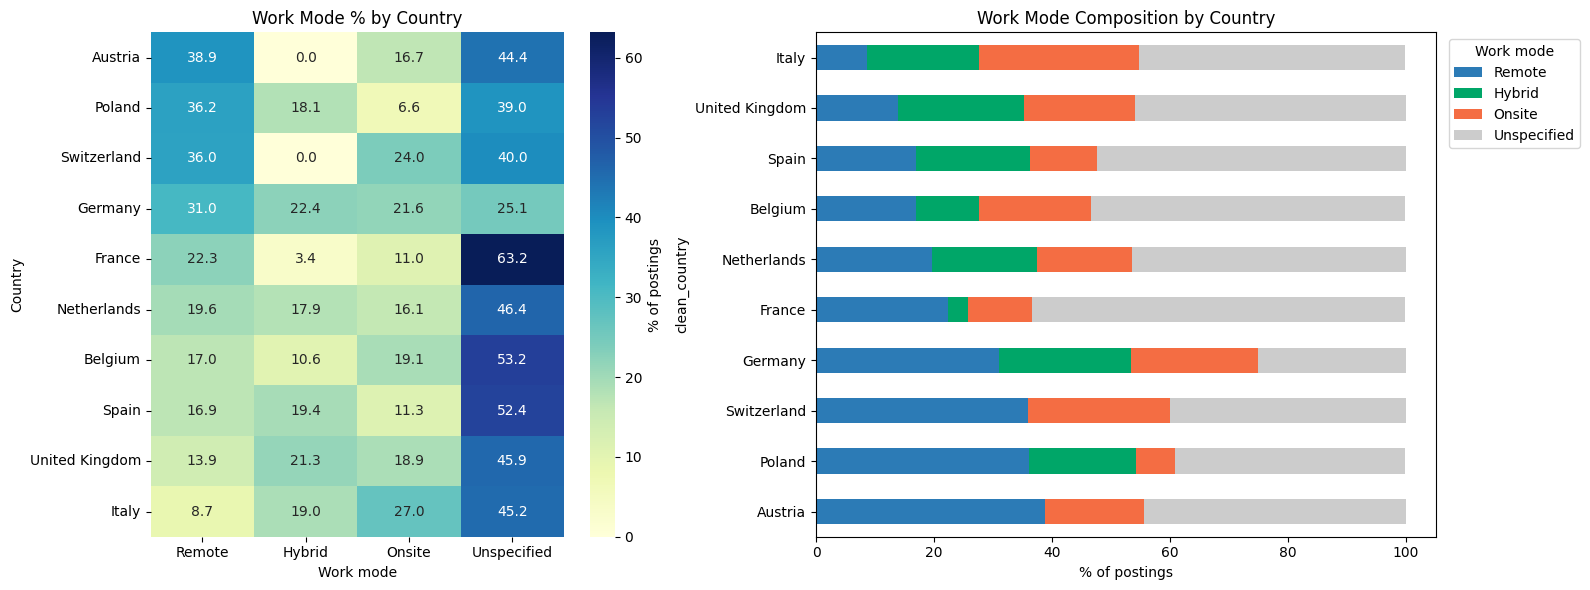

In [71]:


# 4a. Seaborn heatmap of % per country
fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1, 1.2]})
sns.heatmap(
    work_mode_pct, annot=True, fmt=".1f", cmap="YlGnBu",
    cbar_kws={"label": "% of postings"}, ax=axes[0],
)
axes[0].set_title("Work Mode % by Country")
axes[0].set_xlabel("Work mode")
axes[0].set_ylabel("Country")

# 4b. Stacked horizontal bar
work_mode_pct.plot(
    kind="barh", stacked=True, ax=axes[1],
    color=["#2c7bb6", "#00a668", "#f46d43", "#cccccc"],
)
axes[1].set_title("Work Mode Composition by Country")
axes[1].set_xlabel("% of postings")
axes[1].legend(title="Work mode", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 5 - What seniority levels are most requested per country?

% junior / mid / senior per country

In [ ]:
seniority_order = ["Junior", "Middle", "Senior", "Intern", "Unspecified"]

# 1. Pivot table: counts of seniority per country
seniority_counts = data_analyst_jobs.pivot_table(
    index="clean_country",
    columns="seniority_level",
    values="id",
    aggfunc="count",
    fill_value=0,
).reindex(columns=seniority_order, fill_value=0)
seniority_counts.index = seniority_counts.index.map(country_names)

# 2. Row-normalize to % per country
seniority_pct = seniority_counts.div(seniority_counts.sum(axis=1), axis=0) * 100
seniority_pct = seniority_pct.round(1).sort_values("Senior", ascending=False)

# 3. Overall distribution as a Series
overall_seniority = (
    data_analyst_jobs["seniority_level"].value_counts(normalize=True)
    .reindex(seniority_order).mul(100).round(1)
)
print("Overall seniority split (%):")
print(overall_seniority.to_string())

display(seniority_pct)

In [ ]:
# 4a. Seaborn heatmap of % per country
fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1, 1.2]})
sns.heatmap(
    seniority_pct, annot=True, fmt=".1f", cmap="YlOrRd",
    cbar_kws={"label": "% of postings"}, ax=axes[0],
)
axes[0].set_title("Seniority % by Country")
axes[0].set_xlabel("Seniority level")
axes[0].set_ylabel("Country")

# 4b. Stacked horizontal bar
seniority_pct.plot(
    kind="barh", stacked=True, ax=axes[1],
    color=["#00a668", "#74c476", "#f46d43", "#2c7bb6", "#cccccc"],
)
axes[1].set_title("Seniority Composition by Country")
axes[1].set_xlabel("% of postings")
axes[1].legend(title="Seniority", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 6 -Which countries publish the most jobs per week?

In [ ]:
# Use the week start date for clean ordering on the time axis
jobs_weekly = data_analyst_jobs.assign(week=data_analyst_jobs["year_week"].str[:10])
jobs_weekly["country"] = jobs_weekly["clean_country"].map(country_names)

# 1. Pivot table: jobs per week per country
weekly_counts = jobs_weekly.pivot_table(
    index="country",
    columns="week",
    values="id",
    aggfunc="count",
    fill_value=0,
)

# 2. Series: average jobs published per week, per country (the answer)
n_weeks = jobs_weekly["week"].nunique()
avg_jobs_per_week = (weekly_counts.sum(axis=1) / n_weeks).round(1).sort_values(ascending=False)
print(f"Average Data Analyst jobs published per week ({n_weeks} weeks):")
print(avg_jobs_per_week.to_string())

display(weekly_counts)

In [ ]:
# 3. Seaborn line plot: weekly trend per country
plt.figure(figsize=(12, 6))
weekly_long = weekly_counts.T.reset_index().melt(id_vars="week", var_name="country", value_name="jobs")
ax = sns.lineplot(data=weekly_long, x="week", y="jobs", hue="country")
ax.set_title("Data Analyst Jobs per Week by Country")
ax.set_xlabel("Week (start date)")
ax.set_ylabel("Jobs published")
ax.tick_params(axis="x", rotation=90)
ax.legend(title="Country", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# 4. Seaborn bar plot: avg jobs per week per country
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=avg_jobs_per_week.values, y=avg_jobs_per_week.index, palette="viridis")
ax.set_title("Average Jobs per Week by Country")
ax.set_xlabel("Avg jobs / week")
ax.set_ylabel("Country")
plt.tight_layout()
plt.show()